<a href="https://colab.research.google.com/github/misteruzair22/Supply-Chain-Analytics-by-SUA-Fall-2026/blob/main/00-Initial%20Working/Chenab%20PO%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
print("Setup Working:", pd.__version__)

Setup Working: 2.2.3


In [13]:
import pandas as pd

# Open the Excel file to inspect sheet names (already done in previous run)
excel_file = pd.ExcelFile('/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx')

# Print all sheet names to identify the one with actual data (already done)
# print('Available sheets in the Excel file:')
# print(excel_file.sheet_names)

# Load the DataFrame from the 'Procurement_Data' sheet
df = pd.read_excel(
    excel_file,
    sheet_name='Procurement_Data', # Load from the identified data sheet
    header=0  # Assume header is on the first row (0-indexed) for the data sheet
)

# Display the first 5 rows of the DataFrame to understand its structure after correct loading
print('First 5 rows of the dataset after correct loading from \'Procurement_Data\' sheet:')
display(df.head())

# Display general information about the DataFrame, including data types and non-null values
print('\nDataFrame Info after correct loading:')
df.info()

First 5 rows of the dataset after correct loading from 'Procurement_Data' sheet:


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed



DataFrame Info after correct loading:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   PO Number                  10050 non-null  object        
 1   PO Line Item               10050 non-null  int64         
 2   Vendor ID                  10050 non-null  object        
 3   Vendor                     9930 non-null   object        
 4   Plant                      10050 non-null  object        
 5   Department                 10050 non-null  object        
 6   Cost Center                9929 non-null   object        
 7   Requisitioner              10050 non-null  object        
 8   Material Group             9927 non-null   object        
 9   Quantity                   10050 non-null  int64         
 10  Unit Price (PKR)           10050 non-null  int64         
 11  PO Value (PKR)             1

From the initial inspection, it looks like 'Supplier Name' and 'Part Number' are the relevant columns for our analysis. Let's check for any missing values in these columns and proceed with the calculation.

In [14]:
# Check for missing values in 'Vendor' (Supplier Name) and 'Material Group' (Part Number)
print('Missing values before cleaning:')
print(df[['Vendor', 'Material Group']].isnull().sum())

# Drop rows where either 'Vendor' or 'Material Group' is missing
df_cleaned = df.dropna(subset=['Vendor', 'Material Group']).copy()

print('\nMissing values after cleaning:')
print(df_cleaned[['Vendor', 'Material Group']].isnull().sum())

Missing values before cleaning:
Vendor            120
Material Group    123
dtype: int64

Missing values after cleaning:
Vendor            0
Material Group    0
dtype: int64


In [15]:
# Calculate the number of unique parts provided by each supplier
supplier_parts_count = df_cleaned.groupby('Vendor')['Material Group'].nunique().reset_index()

# Sort in descending order to find the top suppliers
top_suppliers = supplier_parts_count.sort_values(by='Material Group', ascending=False)

# Get the top 3 suppliers
top_3_suppliers = top_suppliers.head(3)

print('Top 3 Suppliers by Number of Unique Parts:')
display(top_3_suppliers)

Top 3 Suppliers by Number of Unique Parts:


,Vendor,Material Group
0,Al-Amin Auto Components,10
1,Al-Fateh Machinery,10
3,Al-Noor Fabric Exports,10


Now, let's visualize these top 3 suppliers with a bar chart for better understanding.

/tmp/ipykernel_1043/1140393197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='Material Group', data=top_3_suppliers, palette='viridis')


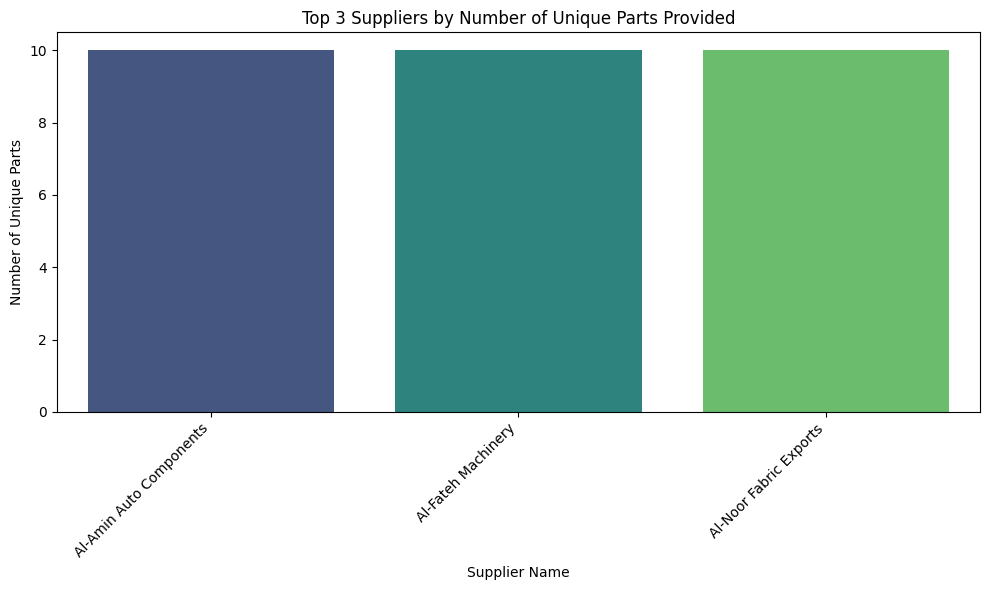

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for the top 3 suppliers
plt.figure(figsize=(10, 6))
sns.barplot(x='Vendor', y='Material Group', data=top_3_suppliers, palette='viridis')
plt.title('Top 3 Suppliers by Number of Unique Parts Provided')
plt.xlabel('Supplier Name')
plt.ylabel('Number of Unique Parts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Summary Table of Top 3 Suppliers

Here is the final summary table showing the top 3 suppliers and the number of unique parts they provide:

In [17]:
# Display the final summary table
display(top_3_suppliers)

,Vendor,Material Group
0,Al-Amin Auto Components,10
1,Al-Fateh Machinery,10
3,Al-Noor Fabric Exports,10


In [20]:
import pandas as pd
df = pd.read_excel(
    "/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx",
    sheet_name="Procurement_Data"
)
print(df.shape)
print(df.head())

(10050, 22)
   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...

### Key Metrics Calculation

We will calculate the following metrics from the dataset:

1.  **Total PO Spend**: The sum of all `PO Value (PKR)` entries, representing the total money spent across all purchase orders.
2.  **Total Number of POs**: The count of unique purchase order numbers (`PO Number`).
3.  **Total Number of Vendors**: The count of unique vendor names (`Vendor`).
4.  **Average PO Value**: The average value per unique purchase order. This is calculated by first summing `PO Value (PKR)` for each unique `PO Number` to get total PO values, and then averaging these sums.
5.  **Average Line-Item Value**: The average value of individual line items, which is the mean of the `PO Value (PKR)` column.

In [21]:
# 1. Calculate Total PO Spend (sum of all line item values)
total_po_spend = df['PO Value (PKR)'].sum()

# 2. Calculate Total Number of POs (count of unique PO numbers)
total_num_pos = df['PO Number'].nunique()

# 3. Calculate Total Number of Vendors (count of unique vendor names)
total_num_vendors = df['Vendor'].nunique()

# 4. Calculate Average PO Value (average of total value per unique PO)
# First, group by 'PO Number' and sum 'PO Value (PKR)' to get total value per PO
po_total_values = df.groupby('PO Number')['PO Value (PKR)'].sum()
# Then, calculate the average of these total PO values
average_po_value = po_total_values.mean()

# 5. Calculate Average Line-Item Value (mean of 'PO Value (PKR)' for all line items)
average_line_item_value = df['PO Value (PKR)'].mean()

# Display the calculated metrics
print(f"Total PO Spend: {total_po_spend:,.2f} PKR")
print(f"Total Number of POs: {total_num_pos}")
print(f"Total Number of Vendors: {total_num_vendors}")
print(f"Average PO Value: {average_po_value:,.2f} PKR")
print(f"Average Line-Item Value: {average_line_item_value:,.2f} PKR")

Total PO Spend: 614,670,044.11 PKR
Total Number of POs: 7406
Total Number of Vendors: 60
Average PO Value: 82,996.23 PKR
Average Line-Item Value: 61,161.20 PKR


### Top 10 Vendors by Total PO Value

Now, let's identify and visualize the top 10 vendors based on their total Purchase Order (PO) Value.

In [22]:
# Calculate the total PO Value for each vendor
vendor_po_value = df.groupby('Vendor')['PO Value (PKR)'].sum().reset_index()

# Sort in descending order to find the top vendors
top_vendors_by_po_value = vendor_po_value.sort_values(by='PO Value (PKR)', ascending=False)

# Get the top 10 vendors
top_10_vendors = top_vendors_by_po_value.head(10)

print('Top 10 Vendors by Total PO Value:')
display(top_10_vendors)

Top 10 Vendors by Total PO Value:


,Vendor,PO Value (PKR)
0,Al-Amin Auto Components,1.018835e+08
27,Karachi Steel Traders,5.007253e+07
59,Zaman Brothers Trading,3.586614e+07
5,Anwar Electric Works,3.146678e+07
54,TCS Cargo Services,2.703754e+07
21,Gulistan Logistics,1.972002e+07
51,Speedline Logistics,1.750654e+07
49,Sindh Spinners Co.,1.655498e+07
56,United Rubber Industries,1.587658e+07
31,Modern Fasteners Co.,1.338250e+07


#### Visualization of Top 10 Vendors by Total PO Value

Here is a bar chart visualizing the top 10 vendors by their total PO Value.

/tmp/ipykernel_1043/2519012803.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='PO Value (PKR)', data=top_10_vendors, palette='crest')


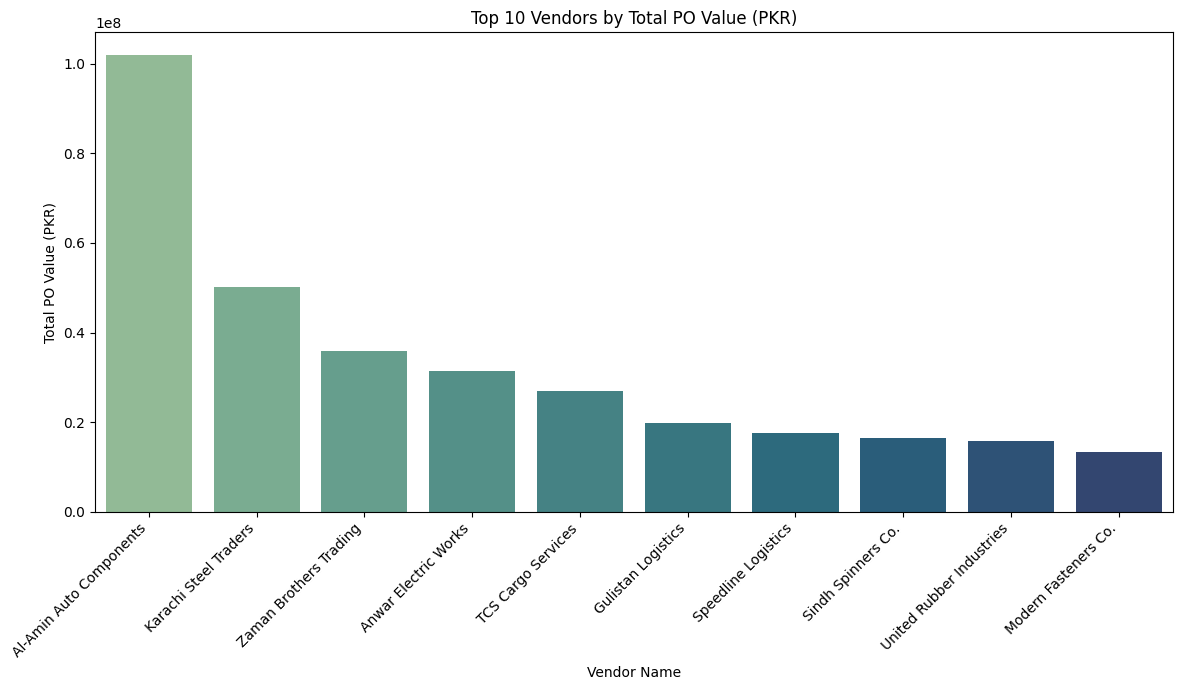

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for the top 10 vendors by PO Value
plt.figure(figsize=(12, 7))
sns.barplot(x='Vendor', y='PO Value (PKR)', data=top_10_vendors, palette='crest')
plt.title('Top 10 Vendors by Total PO Value (PKR)')
plt.xlabel('Vendor Name')
plt.ylabel('Total PO Value (PKR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Pareto Analysis of Vendors by PO Value

Let's perform a Pareto analysis to identify the key vendors contributing to the majority of the total PO spend. This analysis helps in understanding which vendors are most critical to manage.

In [24]:
# Sort vendors by PO Value in descending order (already done as 'top_vendors_by_po_value')

# Calculate the cumulative sum of 'PO Value (PKR)'
top_vendors_by_po_value['Cumulative PO Value'] = top_vendors_by_po_value['PO Value (PKR)'].cumsum()

# Calculate the cumulative percentage of total spend
top_vendors_by_po_value['Cumulative Percentage'] = (top_vendors_by_po_value['Cumulative PO Value'] / total_po_spend) * 100

# Identify vendors contributing to approximately 80% of total spend
pareto_vendors = top_vendors_by_po_value[top_vendors_by_po_value['Cumulative Percentage'] <= 80]

print('Pareto Analysis: Vendors contributing up to 80% of Total PO Spend:')
display(pareto_vendors)

Pareto Analysis: Vendors contributing up to 80% of Total PO Spend:


,Vendor,PO Value (PKR),Cumulative PO Value,Cumulative Percentage
0,Al-Amin Auto Components,1.018835e+08,1.018835e+08,16.575317
27,Karachi Steel Traders,5.007253e+07,1.519560e+08,24.721562
59,Zaman Brothers Trading,3.586614e+07,1.878222e+08,30.556586
5,Anwar Electric Works,3.146678e+07,2.192890e+08,35.675882
54,TCS Cargo Services,2.703754e+07,2.463265e+08,40.074590
21,Gulistan Logistics,1.972002e+07,2.660465e+08,43.282819
51,Speedline Logistics,1.750654e+07,2.835531e+08,46.130939
49,Sindh Spinners Co.,1.655498e+07,3.001080e+08,48.824251
56,United Rubber Industries,1.587658e+07,3.159846e+08,51.407194
31,Modern Fasteners Co.,1.338250e+07,3.293671e+08,53.584379


#### Visualization of Pareto Analysis

Below is a visualization illustrating the cumulative spend percentage of vendors, highlighting those that contribute to the first 80% of the total PO value.

/tmp/ipykernel_1043/1550763799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='PO Value (PKR)', data=top_vendors_by_po_value.head(len(pareto_vendors) + 5), palette='viridis', ax=ax1)
/tmp/ipykernel_1043/1550763799.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors_by_po_value.head(len(pareto_vendors) + 5)['Vendor'], rotation=45, ha='right')


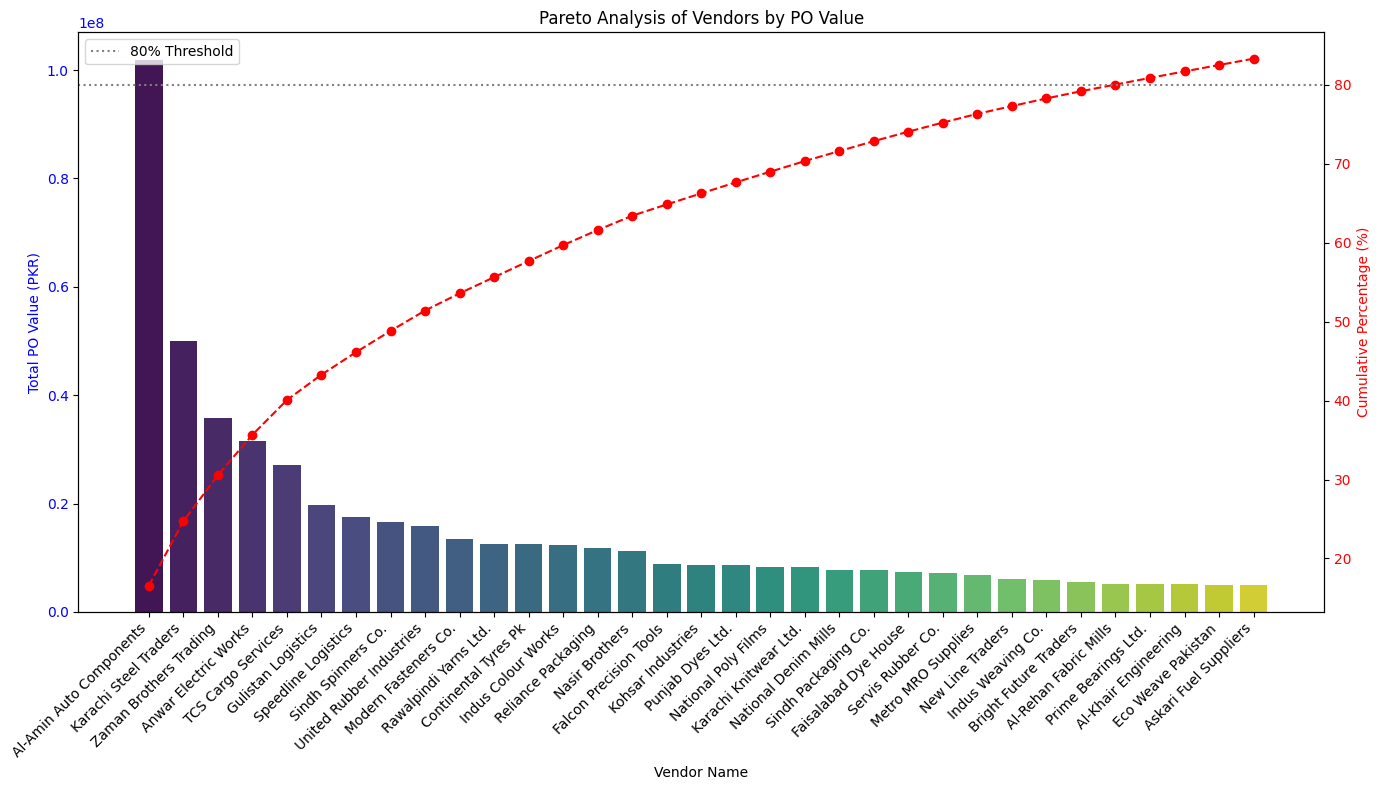

In [25]:
fig, ax1 = plt.subplots(figsize=(14, 8))

sns.barplot(x='Vendor', y='PO Value (PKR)', data=top_vendors_by_po_value.head(len(pareto_vendors) + 5), palette='viridis', ax=ax1)
ax1.set_xlabel('Vendor Name')
ax1.set_ylabel('Total PO Value (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis of Vendors by PO Value')
ax1.set_xticklabels(top_vendors_by_po_value.head(len(pareto_vendors) + 5)['Vendor'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(top_vendors_by_po_value['Vendor'].head(len(pareto_vendors) + 5), top_vendors_by_po_value['Cumulative Percentage'].head(len(pareto_vendors) + 5), color='red', marker='o', linestyle='--')
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for visual reference
ax2.axhline(y=80, color='gray', linestyle=':', label='80% Threshold')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Total Number of Suppliers

In [26]:
print(f"Total Number of Suppliers: {total_num_vendors}")

Total Number of Suppliers: 60
